In [1]:
# Mount Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install & Import Libraries

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, BatchNormalization,
                                      Dropout, Dense, Flatten, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import os

print(" TensorFlow version:", tf.__version__)
print(" GPU:", tf.config.list_physical_devices('GPU'))

 TensorFlow version: 2.20.0
 GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Set Paths & Parameters

# Paths
base = '/content/drive/MyDrive/advanced_banana_quality_project'
train_dir = f'{base}/data/classification/train'
val_dir   = f'{base}/data/classification/val'
test_dir  = f'{base}/data/classification/test'

# Parameters
IMG_SIZE   = (224, 224)  # standard size for CNN
BATCH_SIZE = 32
EPOCHS     = 30
NUM_CLASSES = 4
CLASS_NAMES = ['overripe', 'ripe', 'rotten', 'unripe']

print(" Paths and parameters set!")
print(f"   Image Size  : {IMG_SIZE}")
print(f"   Batch Size  : {BATCH_SIZE}")
print(f"   Epochs      : {EPOCHS}")
print(f"   Classes     : {NUM_CLASSES} → {CLASS_NAMES}")

 Paths and parameters set!
   Image Size  : (224, 224)
   Batch Size  : 32
   Epochs      : 30
   Classes     : 4 → ['overripe', 'ripe', 'rotten', 'unripe']


In [4]:
# Data Augmentation & Generators

# Train augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Val & Test — only rescale (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\n Data generators ready!")
print(f"   Class indices: {train_generator.class_indices}")

Found 11793 images belonging to 4 classes.
Found 1123 images belonging to 4 classes.
Found 562 images belonging to 4 classes.

 Data generators ready!
   Class indices: {'overripe': 0, 'ripe': 1, 'rotten': 2, 'unripe': 3}


In [5]:
# Build Custom CNN

model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 26,410,020 (100.75 MB)

 Trainable params: 26,407,588 (100.74 MB)

 Non-trainable params: 2,432 (9.50 KB)

In [6]:
# Class Weights (handle imbalance)

from sklearn.utils.class_weight import compute_class_weight

# Get class labels from training generator
train_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_array))
print(" Class weights:", class_weights)

 Class weights: {0: np.float64(1.2551085568326947), 1: np.float64(0.8370954003407155), 2: np.float64(0.7333955223880597), 3: np.float64(1.5500788643533123)}


In [7]:
# Callbacks

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=f'{base}/models/custom_cnn_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print(" Callbacks ready!")

 Callbacks ready!


In [8]:
# Train the Model

print(" Starting training...")

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("\n Training complete!")

 Starting training...
Epoch 1/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 13s/step - accuracy: 0.6838 - loss: 0.9144 
Epoch 1: val_accuracy improved from None to 0.49955, saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/custom_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/custom_cnn_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 5354s 14s/step - accuracy: 0.7602 - loss: 0.6870 - val_accuracy: 0.4996 - val_loss: 1.8899 - learning_rate: 0.0010
Epoch 2/30
369/369 ━━━━━━━━━━━━━━━━━━━━ 0s 569ms/step - accuracy: 0.8446 - loss: 0.4076
Epoch 2: val_accuracy improved from 0.49955 to 0.82102, saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/custom_cnn_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/advanced_banana_quality_project/models/custom_cnn_model.keras
369/369 ━━━━━━━━━━━━━━━━━━━━ 217s 588ms/step - accuracy: 0.8510 - loss: 0.3995 - val_accuracy: 0.8210 - val_

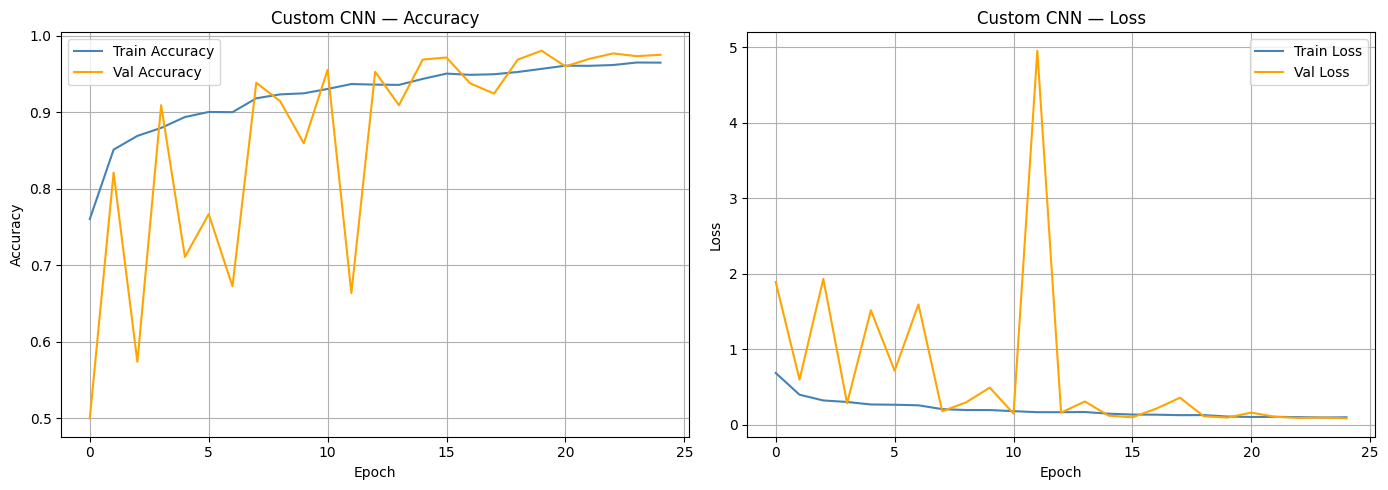

 Training curves saved!


In [9]:
# Plot Training Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[0].set_title('Custom CNN — Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[1].set_title('Custom CNN — Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f'{base}/screenshots/custom_cnn_training_curves.png')
plt.show()
print(" Training curves saved!")

18/18 ━━━━━━━━━━━━━━━━━━━━ 189s 11s/step

 Classification Report:
              precision    recall  f1-score   support

    overripe       0.93      0.98      0.96       113
        ripe       0.99      0.98      0.98       154
      rotten       0.99      0.96      0.97       185
      unripe       0.98      0.99      0.99       110

    accuracy                           0.98       562
   macro avg       0.97      0.98      0.97       562
weighted avg       0.98      0.98      0.98       562



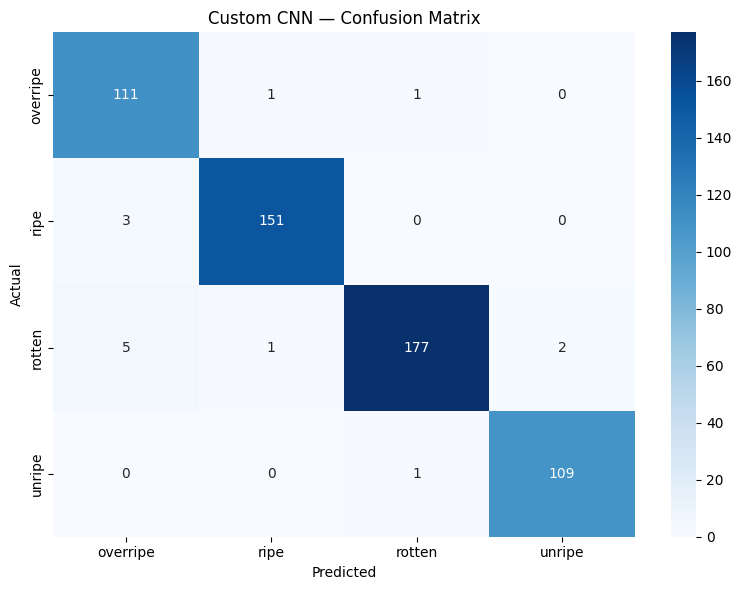

 Confusion matrix saved!


In [10]:
#  Evaluate on Test Set

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predict
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Classification Report
print("\n Classification Report:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Custom CNN — Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(f'{base}/screenshots/custom_cnn_confusion_matrix.png')
plt.show()
print(" Confusion matrix saved!")

In [12]:
# Save Final Results

# Test accuracy
test_loss, test_accuracy = model.evaluate(test_generator, verbose=0)
print(f" Custom CNN Results:")
print(f"   Test Accuracy : {test_accuracy*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")

# Save results summary
import json
results = {
    'model': 'Custom CNN',
    'test_accuracy': round(test_accuracy*100, 2),
    'test_loss': round(test_loss, 4),
    'epochs_trained': len(history.history['accuracy']),
    'img_size': '224x224',
    'batch_size': BATCH_SIZE
}

with open(f'{base}/reports/custom_cnn_results.json', 'w') as f:
    json.dump(results, f, indent=4)

print(" Results saved to reports folder!")

 Custom CNN Results:
   Test Accuracy : 97.51%
   Test Loss     : 0.0871
 Results saved to reports folder!
